In [458]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

df = pd.read_csv("GEDEvent_v25_1.csv")

C:\Users\tolot\AppData\Local\Temp\ipykernel_25296\2293759986.py:7: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("GEDEvent_v25_1.csv")


##  <font color="#fbff00">1. Exploration </font>

###  <font color="#ff8800"> Basic Description </font>

In [459]:
print("=== First rows ===")
display(df.head(3))

=== First rows ===


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN


In [460]:
print("\n=== Dataset Shape (rows, columns) ===")
display(df.shape)

print("\n=== Dataset Columns ===")
display(df.columns)




=== Dataset Shape (rows, columns) ===


(385918, 49)


=== Dataset Columns ===


Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')

In [461]:
# Numerical columns summary
print("\n=== Summary Statistics (Numerical Columns) ===")
df.describe().round(2)


=== Summary Statistics (Numerical Columns) ===


,id,year,type_of_violence,conflict_dset_id,conflict_new_id,dyad_dset_id,dyad_new_id,side_a_dset_id,side_a_new_id,side_b_dset_id,...,event_clarity,date_prec,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnob
count,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,...,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,385918.00,30256.00
mean,290595.57,2012.49,1.45,3876.81,3893.46,6744.22,6993.74,633.19,633.19,3296.49,...,1.08,1.22,2.47,2.25,3.82,1.72,10.25,15.12,8.54,389.52
std,158412.34,9.41,0.75,5885.53,5774.83,6468.05,6475.38,1705.34,1705.34,3658.77,...,0.27,0.65,254.72,53.76,178.40,99.62,347.68,426.86,313.66,85.85
min,2.00,1989.00,1.00,6.00,205.00,6.00,406.00,3.00,3.00,3.00,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
25%,162928.25,2007.00,1.00,299.00,299.00,735.00,781.00,109.00,109.00,303.00,...,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,369.00
50%,293210.50,2014.00,1.00,333.00,386.00,5188.00,5226.00,118.00,118.00,775.00,...,1.00,1.00,0.00,0.00,0.00,0.00,2.00,2.00,2.00,369.00
75%,422042.75,2020.00,2.00,5583.00,4979.00,14117.00,14117.00,154.00,154.00,5914.00,...,1.00,1.00,0.00,1.00,1.00,0.00,4.00,5.00,4.00,369.00
max,572006.00,2024.00,3.00,18362.00,16527.00,18362.00,18362.00,9363.00,9363.00,9999.00,...,2.00,5.00,121848.00,19874.00,40000.00,48183.00,121848.00,121848.00,121848.00,800.00


In [462]:
df.describe(include='string').T

,count,unique,top,freq
relid,385918,385918,IRQ-2017-1-524-322,1
code_status,385918,1,Clear,385918
conflict_name,385918,1529,Syria: Government,66186
dyad_name,385918,1771,Government of Syria - Syrian insurgents,66186
side_a,385918,966,Government of Syria,75181
side_b,385918,959,Syrian insurgents,66186
source_article,385917,255147,"""Balkan Battlegrounds: A Military History of t...",4123
source_office,288005,24027,SOHR,29640
source_date,288005,48785,2002-11-01;2012-11-01,5410
source_headline,288000,185443,Volume I and II;Bosnian Book of the Dead,4127


###  <font color="#ff8800"> Feature Type Count </font>

In [463]:
# Conteo de tipos de variables

print("\n=== Conteo de tipos de variables ===")
display(df.dtypes.value_counts())

print("\n=== Variables numéricas ===")
display(df.select_dtypes(include=["number"]).columns)

print("\n=== Variables categóricas ===")
display(df.select_dtypes(include=["object", "category", "string"]).columns)

print("\n=== Variables booleanas ===")
display(df.select_dtypes(include=["bool"]).columns)

print("\n=== Variables de fecha ===")
display(df.select_dtypes(include=["datetime"]).columns)


=== Conteo de tipos de variables ===


int64      24
str        20
float64     3
bool        1
object      1
Name: count, dtype: int64


=== Variables numéricas ===


Index(['id', 'year', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id',
       'dyad_dset_id', 'dyad_new_id', 'side_a_dset_id', 'side_a_new_id',
       'side_b_dset_id', 'side_b_new_id', 'number_of_sources', 'where_prec',
       'latitude', 'longitude', 'priogrid_gid', 'country_id', 'event_clarity',
       'date_prec', 'deaths_a', 'deaths_b', 'deaths_civilians',
       'deaths_unknown', 'best', 'high', 'low', 'gwnob'],
      dtype='str')


=== Variables categóricas ===


Index(['relid', 'code_status', 'conflict_name', 'dyad_name', 'side_a',
       'side_b', 'source_article', 'source_office', 'source_date',
       'source_headline', 'source_original', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'geom_wkt', 'country', 'region',
       'date_start', 'date_end', 'gwnoa'],
      dtype='str')


=== Variables booleanas ===


Index(['active_year'], dtype='str')


=== Variables de fecha ===


Index([], dtype='str')

###  <font color="#ff8800"> Errors, Outliers and Missing Values </font>

In [464]:
# Duplicates
print("=== Duplicated rows ===")
duplicados = df.duplicated().sum()
print("Duplicated rows amount:", duplicados)

# Missing values
print("\n=== Missing Values ===")
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data.reset_index().rename(columns={'index': 'Column'})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)

# IQR Outliers
print("\n=== Numeric Features Outliers ===")
df_num = df.select_dtypes(include="number")

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR)))

# Filter columns with more than 10% outliers

outliers_data = pd.DataFrame({
    'Outliers_count': outliers_mask.sum(),
    'Outliers_Percentage': (outliers_mask.sum() / len(df) * 100).round(2)
})

outliers_data = outliers_data.reset_index().rename(columns={'index': 'Column'})

outliers_data = outliers_data[outliers_data['Outliers_Percentage'] > 10].sort_values('Outliers_count', ascending=False)
print(outliers_data.head(10))


=== Duplicated rows ===
Duplicated rows amount: 0

=== Missing Values ===
               Column  Missing_Count  Missing_Percentage
48              gwnob         355662               92.16
22    source_headline          97918               25.37
21        source_date          97913               25.37
20      source_office          97913               25.37
47              gwnoa          93411               24.20
28              adm_2          69977               18.13
23    source_original          44244               11.46
27              adm_1          19547                5.07
26  where_description          10243                2.65
19     source_article              1                0.00

=== Numeric Features Outliers ===
              Column  Outliers_count  Outliers_Percentage
7     side_a_dset_id          102119                26.46
8      side_a_new_id          102119                26.46
19          deaths_a           94908                24.59
4    conflict_new_id           9

In [465]:
# Remove ID-like columns
df_num = df_num.loc[:, ~df_num.columns.str.contains('id', case=False)]

# Compute IQR
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

# Outlier mask
outliers_mask = ((df_num < (Q1 - 1.5 * IQR)) | 
                 (df_num > (Q3 + 1.5 * IQR)))

# Summary table
outliers_data = pd.DataFrame({
    'Outliers_count': outliers_mask.sum(),
    'Outliers_Percentage': (outliers_mask.sum() / len(df) * 100).round(2)
})

outliers_data = outliers_data.reset_index().rename(columns={'index': 'Column'})

outliers_data = outliers_data[outliers_data['Outliers_Percentage'] > 10].sort_values('Outliers_count', ascending=False)
print(outliers_data.head(10))

              Column  Outliers_count  Outliers_Percentage
8           deaths_a           94908                24.59
7          date_prec           57245                14.83
9           deaths_b           57128                14.80
11    deaths_unknown           56401                14.61
5          longitude           54154                14.03
12              best           50210                13.01
14               low           46614                12.08
13              high           45916                11.90
10  deaths_civilians           40484                10.49


## <font color="#cc00ff"> Dataset Summary – EDA </font>

---

## Información General

**Tamaño del dataset:** 385,918 filas × 49 columnas

**Tipos de variables:**

| Tipo       | Cantidad |
|-----------|----------|
| Numéricas | 24       |
| Categóricas / Texto | 20 |
| Flotantes | 3        |
| Booleanas | 1        |
| Objeto    | 1        |

**Variables destacadas:**

- **Numéricas:** `type_of_violence, number_of_sources, where_prec, event_clarity, date_prec, best, deaths_a, deaths_b, deaths_civilians, deaths_unknown ...`
- **Categóricas:** `source_date, where_coordinates, where_description, source_date, country, region, date_start, date_end ...`

**Valores nulos más relevantes:**

| Variable           | % Nulos |
|------------------|--------|
| gwnob             | 92%    |
| source_office     | 25%    |
| source_date       | 25%    |
| source_headline   | 25%    |
| adm_2             | 18%    |

**Curiosidad:**  
- Algunas variables numéricas (`deaths_a`, `deaths_b`, `number_of_sources`) presentan una cantidad significativa de outliers.

##  <font color="#fbff00">2. Data Visualization </font>

###  <font color="#ff8800"> Feature Selection and Removal Rationale </font>



Several variables were removed from the dataset prior to analysis in order to improve data quality, interpretability, and modeling relevance.

#### Deprecated and Non-Operational Variables
The following variables were explicitly documented as deprecated or not intended for use in the current dataset version (UCDP GED 25.1 API):

- relid  
- code_status  
- conflict_dset_id  
- dyad_dset_id  
- side_a_dset_id  
- side_b_dset_id  

These variables are either legacy identifiers from previous dataset versions or internal-use fields with no analytical relevance. Including them could introduce noise or confusion without contributing meaningful information.

#### Geospatial and Technical Representation Features

- priogrid_gid  
- geom_wkt  

Although these variables contain spatial information, they were removed for the following reasons:
  
- **priogrid_gid** is a spatial indexing reference tied to an external grid system (PRIO-GRID), which requires additional datasets and careful handling to avoid inconsistencies.
  
- **geom_wkt** is a technical geometric representation intended for GIS systems, not for statistical analysis.

Since this analysis does not focus on spatial modeling, these variables were excluded to maintain clarity and avoid introducing misleading patterns.


In [466]:
drop_cols = [
    'relid',
    'code_status',
    'conflict_dset_id',
    'dyad_dset_id',
    'side_a_dset_id',
    'side_b_dset_id',
    'priogrid_gid',
    'geom_wkt'
]

df = df.drop(columns=drop_cols,errors='ignore')

print("\n=== Dataset Shape (rows, columns) ===")
display(df.shape)

print("\n=== Dataset Columns ===")
display(df.columns)

print("\n=== Conteo de tipos de variables ===")
display(df.dtypes.value_counts())


=== Dataset Shape (rows, columns) ===


(385918, 41)


=== Dataset Columns ===


Index(['id', 'year', 'active_year', 'type_of_violence', 'conflict_new_id',
       'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a',
       'side_b_new_id', 'side_b', 'number_of_sources', 'source_article',
       'source_office', 'source_date', 'source_headline', 'source_original',
       'where_prec', 'where_coordinates', 'where_description', 'adm_1',
       'adm_2', 'latitude', 'longitude', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')


=== Conteo de tipos de variables ===


int64      19
str        17
float64     3
bool        1
object      1
Name: count, dtype: int64

###  <font color="#ff8800"> Errores, Outliers y Faltantes </font>

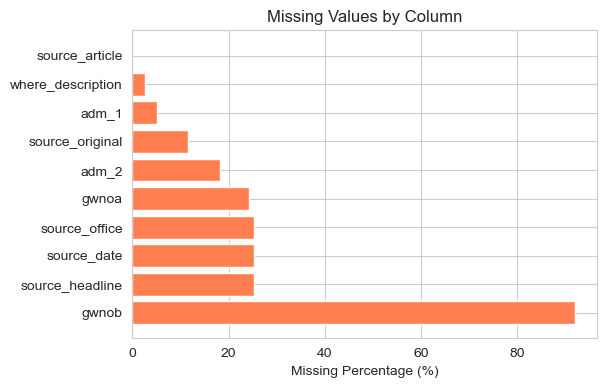

In [467]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.barh(
    missing_data['Column'],
    missing_data['Missing_Percentage'],
    color='coral'
)

ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column')

plt.show()

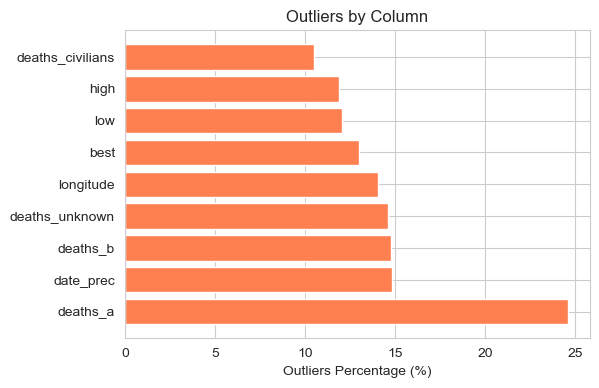

In [468]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.barh(
    outliers_data['Column'],
    outliers_data['Outliers_Percentage'],
    color='coral'
)

ax.set_xlabel('Outliers Percentage (%)')
ax.set_title('Outliers by Column')

plt.show()

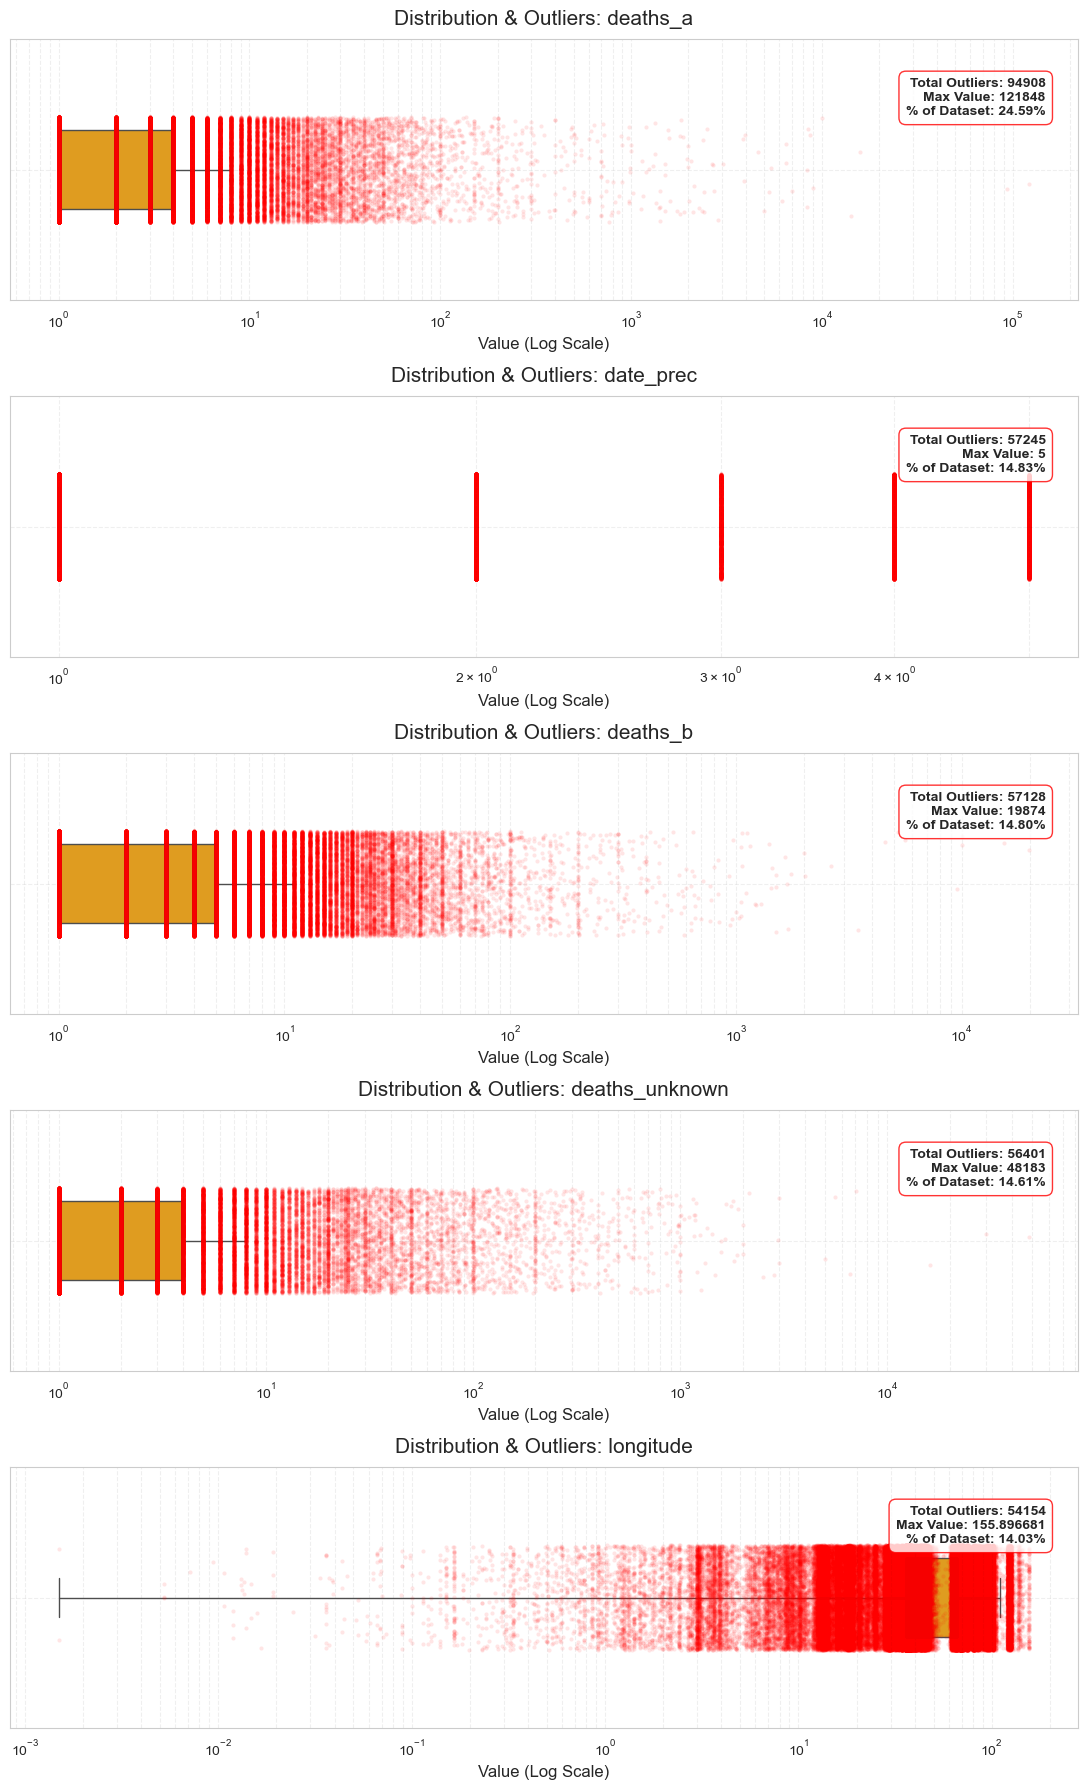

In [469]:
# Assuming top5_cols is already defined
top5_cols = outliers_data.head(5)['Column']

fig, axes = plt.subplots(len(top5_cols), 1, figsize=(11, 18))

for i, col in enumerate(top5_cols):
    ax = axes[i]
    data_col = df_num[col].dropna()
    
    # We need to filter out 0s for the log scale to work properly on the axis
    # or use a very small value. Here we use data > 0 for the visual.
    plot_data = data_col[data_col > 0]
    
    # --- Calculate Stats for the Info Box ---
    q1 = data_col.quantile(0.25)
    q3 = data_col.quantile(0.75)
    iqr = q3 - q1
    num_outliers = ((data_col < (q1 - 1.5 * iqr)) | (data_col > (q3 + 1.5 * iqr))).sum()
    max_val = data_col.max()
    perc_outliers = (num_outliers / len(data_col)) * 100

    # 1. Base Boxplot (Orange)
    sns.boxplot(x=plot_data, ax=ax, color='orange', width=0.3, 
                flierprops={'marker': '', 'alpha':0}) 

    # 2. Stripplot (Red dots)
    sns.stripplot(x=plot_data, ax=ax, color='red', alpha=0.1, jitter=0.2, size=3)

    # 3. Logarithmic Scale
    ax.set_xscale('log')

    # 4. Titles and Labels
    ax.set_title(f'Distribution & Outliers: {col}', fontsize=15, pad=10)
    ax.set_xlabel('Value (Log Scale)', fontsize=12)

    # 5. Technical Info Box
    info_text = (f'Total Outliers: {num_outliers}\n'
                 f'Max Value: {max_val}\n'
                 f'% of Dataset: {perc_outliers:.2f}%')

    ax.text(0.97, 0.85, info_text, transform=ax.transAxes, 
            ha='right', va='top', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.5', alpha=0.8))

    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\tolot\anaconda3\envs\add-env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\tolot\anaconda3\envs\add-env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


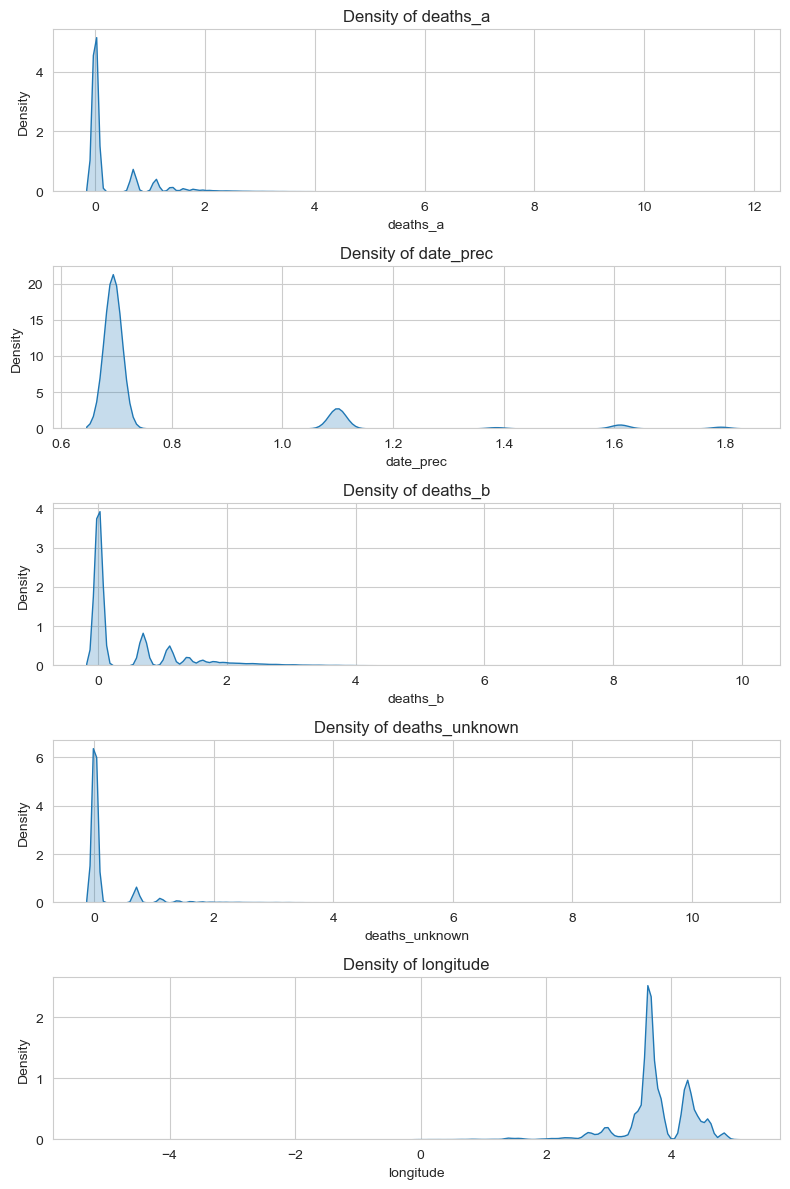

In [470]:
fig, axes = plt.subplots(len(top5_cols), 1, figsize=(8, 12))

for i, col in enumerate(top5_cols):
    sns.kdeplot(np.log1p(df_num[col]), ax=axes[i], fill=True)
    axes[i].set_title(f'Density of {col}')

plt.tight_layout()
plt.show()

###  <font color="#ff8800"> Key Features </font>

####  <font color="#00ffea"> Death </font>

In [471]:
# Deaths analysis
death_cols = ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low']

print("\n=== Deaths Statistics ===")
print(df[death_cols].describe().round(2))



=== Deaths Statistics ===
        deaths_a   deaths_b  deaths_civilians  deaths_unknown       best  \
count  385918.00  385918.00         385918.00       385918.00  385918.00   
mean        2.47       2.25              3.82            1.72      10.25   
std       254.72      53.76            178.40           99.62     347.68   
min         0.00       0.00              0.00            0.00       0.00   
25%         0.00       0.00              0.00            0.00       1.00   
50%         0.00       0.00              0.00            0.00       2.00   
75%         0.00       1.00              1.00            0.00       4.00   
max    121848.00   19874.00          40000.00        48183.00  121848.00   

            high        low  
count  385918.00  385918.00  
mean       15.12       8.54  
std       426.86     313.66  
min         0.00       0.00  
25%         1.00       1.00  
50%         2.00       2.00  
75%         5.00       4.00  
max    121848.00  121848.00  


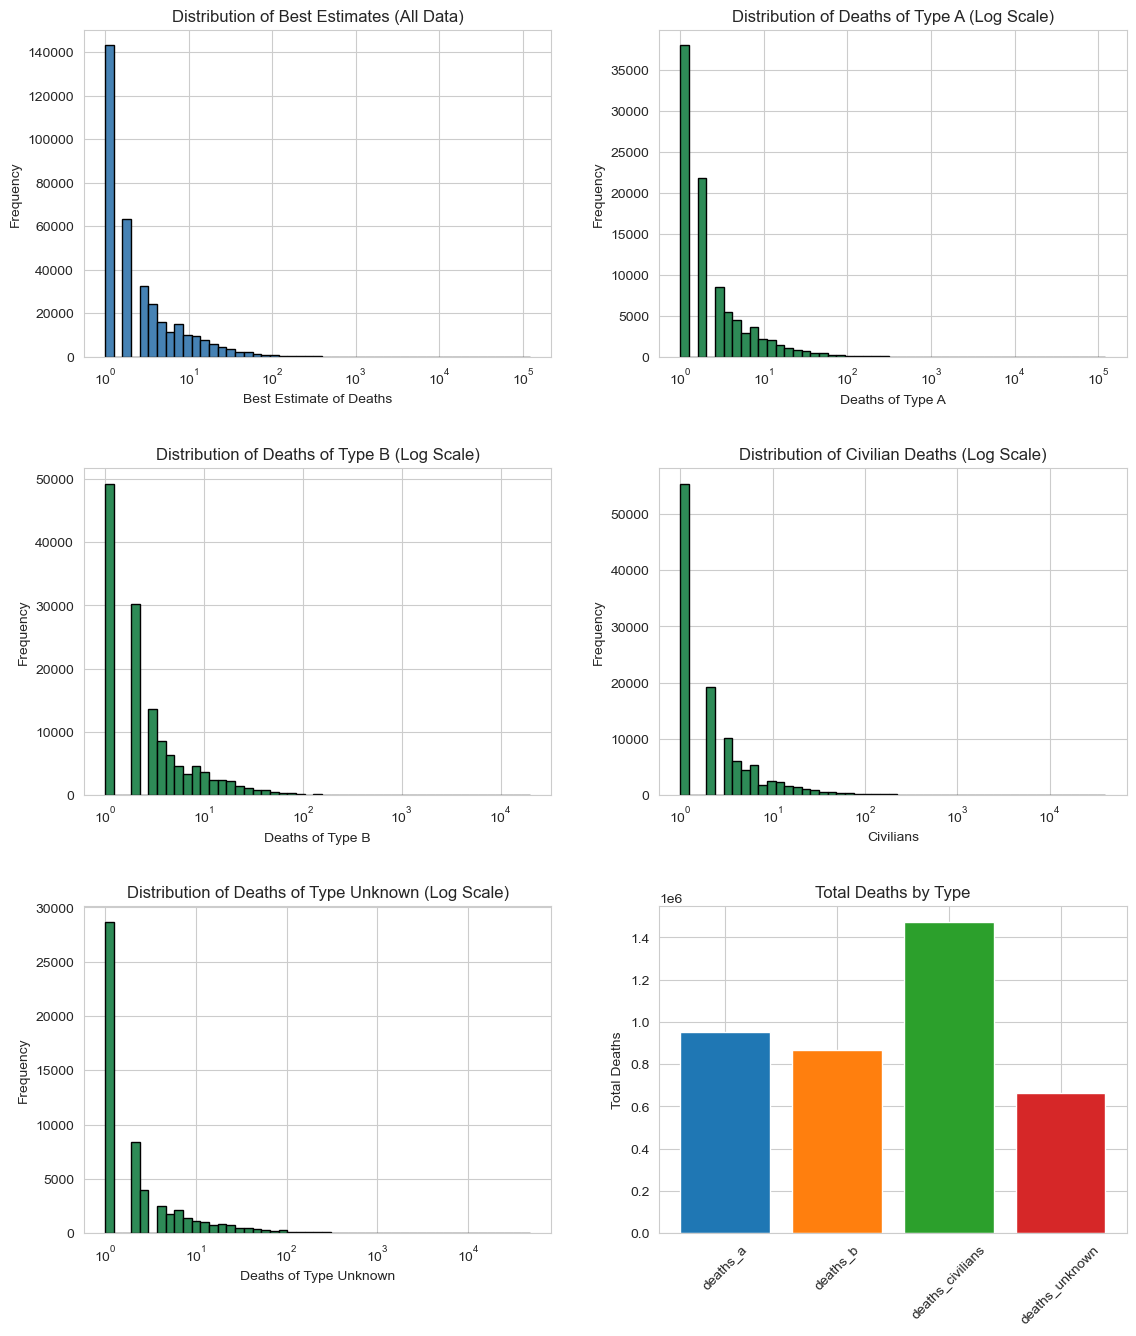

In [472]:
# Distribution of best estimates of deaths
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# Best deaths
bins = np.logspace(np.log10(df[df['best'] > 0]['best'].min()), np.log10(df[df['best'] > 0]['best'].max()), 50)
axes[0, 0].hist(df[df['best'] > 0]['best'], bins=bins, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Best Estimate of Deaths')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Best Estimates (All Data)')
#axes[0, 0].set_yscale('log')
axes[0, 0].set_xscale('log')

# Best deaths (log scale on x)
bins = np.logspace(np.log10(df[df['deaths_a'] > 0]['deaths_a'].min()), np.log10(df[df['deaths_a'] > 0]['deaths_a'].max()), 50)
axes[0, 1].hist(df[df['deaths_a'] > 0]['deaths_a'], bins=bins, color='seagreen', edgecolor='black')
axes[0, 1].set_xlabel('Deaths of Type A')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Deaths of Type A (Log Scale)')
#axes[0, 1].set_yscale('log')
axes[0, 1].set_xscale('log')

bins = np.logspace(np.log10(df[df['deaths_b'] > 0]['deaths_b'].min()), np.log10(df[df['deaths_b'] > 0]['deaths_b'].max()), 50)
axes[1, 0].hist(df[df['deaths_b'] > 0]['deaths_b'], bins=bins, color='seagreen', edgecolor='black')
axes[1, 0].set_xlabel('Deaths of Type B')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Deaths of Type B (Log Scale)')
#axes[1, 0].set_yscale('log')
axes[1, 0].set_xscale('log')

bins = np.logspace(np.log10(df[df['deaths_civilians'] > 0]['deaths_civilians'].min()), np.log10(df[df['deaths_civilians'] > 0]['deaths_civilians'].max()), 50)
axes[1, 1].hist(df[df['deaths_civilians'] > 0]['deaths_civilians'], bins=bins, color='seagreen', edgecolor='black')
axes[1, 1].set_xlabel('Civilians')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Civilian Deaths (Log Scale)')
#axes[1, 1].set_yscale('log')
axes[1, 1].set_xscale('log')

bins = np.logspace(np.log10(df[df['deaths_unknown'] > 0]['deaths_unknown'].min()), np.log10(df[df['deaths_unknown'] > 0]['deaths_unknown'].max()), 50)
axes[2, 0].hist(df[df['deaths_unknown'] > 0]['deaths_unknown'], bins=bins, color='seagreen', edgecolor='black')
axes[2, 0].set_xlabel('Deaths of Type Unknown')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title('Distribution of Deaths of Type Unknown (Log Scale)')
#axes[2, 0].set_yscale('log')
axes[2, 0].set_xscale('log')

# Deaths by type
death_by_type = df[['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown']].sum()
axes[2, 1].bar(death_by_type.index, death_by_type.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2, 1].set_ylabel('Total Deaths')
axes[2, 1].set_title('Total Deaths by Type')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(pad=3.0) 
plt.show()


####  <font color="#00ffea"> Conflict </font>

In [473]:
# Conflict analysis
conflict_cols = ['type_of_violence', 'conflict_new_id', 'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a',
              'side_b_new_id', 'side_b']

print("\n=== Conflict Statistics ===")
print(df[conflict_cols].describe().round(2))



=== Conflict Statistics ===
       type_of_violence  conflict_new_id  dyad_new_id  side_a_new_id  \
count         385918.00        385918.00    385918.00      385918.00   
mean               1.45          3893.46      6993.74         633.19   
std                0.75          5774.83      6475.38        1705.34   
min                1.00           205.00       406.00           3.00   
25%                1.00           299.00       781.00         109.00   
50%                1.00           386.00      5226.00         118.00   
75%                2.00          4979.00     14117.00         154.00   
max                3.00         16527.00     18362.00        9363.00   

       side_b_new_id  
count      385918.00  
mean         1752.30  
std          2396.03  
min             1.00  
25%           208.00  
50%           338.00  
75%          4456.00  
max          9392.00  


In [474]:
df[conflict_cols].describe(include='string').T

,count,unique,top,freq
conflict_name,385918,1529,Syria: Government,66186
dyad_name,385918,1771,Government of Syria - Syrian insurgents,66186
side_a,385918,966,Government of Syria,75181
side_b,385918,959,Syrian insurgents,66186


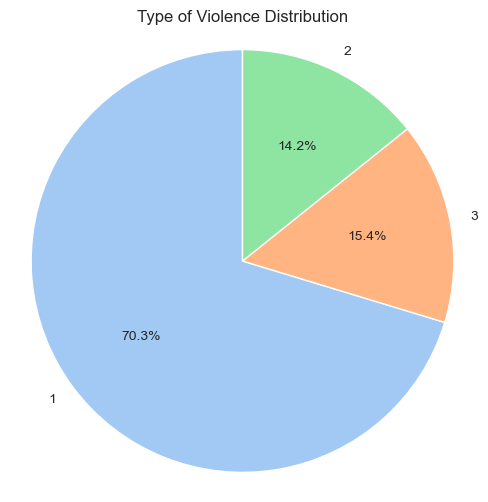

In [475]:
typ_violence_counts = df['type_of_violence'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    typ_violence_counts,
    labels=typ_violence_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

plt.title('Type of Violence Distribution')
plt.axis('equal')

plt.show()

####  <font color="#00ffea"> Information </font>

In [476]:
# Information analysis
info_cols = ['number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'event_clarity',
              'date_prec', 'date_start', 'date_end', 'year', 'active_year']

print("\n=== Information Statistics ===")
print(df[info_cols].describe().round(2))


=== Information Statistics ===
       number_of_sources  event_clarity  date_prec       year
count          385918.00      385918.00  385918.00  385918.00
mean                0.82           1.08       1.22    2012.49
std                 1.65           0.27       0.65       9.41
min                -1.00           1.00       1.00    1989.00
25%                -1.00           1.00       1.00    2007.00
50%                 1.00           1.00       1.00    2014.00
75%                 1.00           1.00       1.00    2020.00
max               361.00           2.00       5.00    2024.00


In [477]:
df[info_cols].describe(include='string').T

,count,unique,top,freq
source_article,385917,255147,"""Balkan Battlegrounds: A Military History of t...",4123
source_office,288005,24027,SOHR,29640
source_date,288005,48785,2002-11-01;2012-11-01,5410
source_headline,288000,185443,Volume I and II;Bosnian Book of the Dead,4127
source_original,341674,57447,SOHR,37691
date_start,385918,13142,2014-08-29 00:00:00.000,281
date_end,385918,13145,2014-08-29 00:00:00.000,280


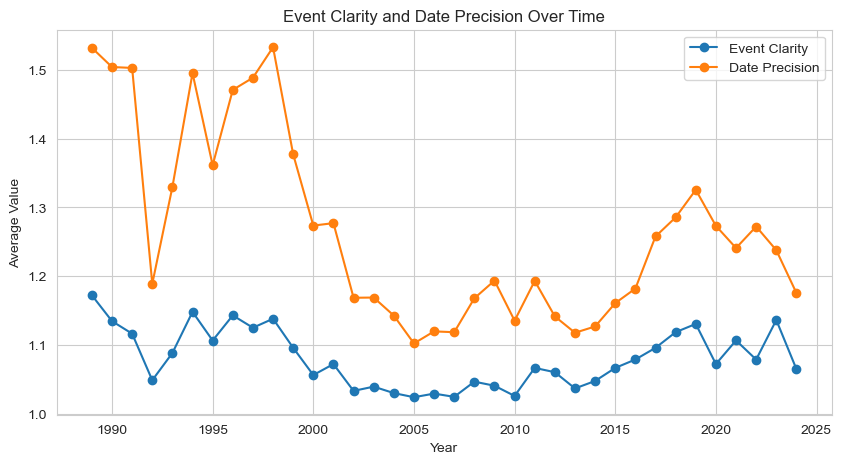

In [478]:
yearly_stats = df.groupby('year')[['event_clarity', 'date_prec']].mean().reset_index()

plt.figure(figsize=(10, 5))

plt.plot(yearly_stats['year'], yearly_stats['event_clarity'], marker='o', label='Event Clarity')
plt.plot(yearly_stats['year'], yearly_stats['date_prec'], marker='o', label='Date Precision')

plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Event Clarity and Date Precision Over Time')

plt.legend()
plt.grid(True)

plt.show()

####  <font color="#00ffea"> Location </font>

In [479]:
# Location analysis
loc_cols = ['where_prec', 'where_coordinates', 'where_description', 'country', 'country_id', 'region', 'longitude', 'latitude']

print("\n=== Location Statistics ===")
print(df[loc_cols].describe().round(2))


=== Location Statistics ===
       where_prec  country_id  longitude   latitude
count   385918.00   385918.00  385918.00  385918.00
mean         2.05      544.63      29.65      26.09
std          1.26      212.16      49.51      16.05
min          1.00        2.00    -117.30     -37.81
25%          1.00      372.00      29.17      13.36
50%          2.00      652.00      37.05      33.00
75%          3.00      700.00      62.20      35.78
max          7.00      940.00     155.90      68.98


In [480]:
df[loc_cols].describe(include='string').T

,count,unique,top,freq
where_coordinates,385918,54511,Aleppo town,4452
where_description,375675,224241,Mosul town,1125
country,385918,124,Syria,87861
region,385918,5,Middle East,122215


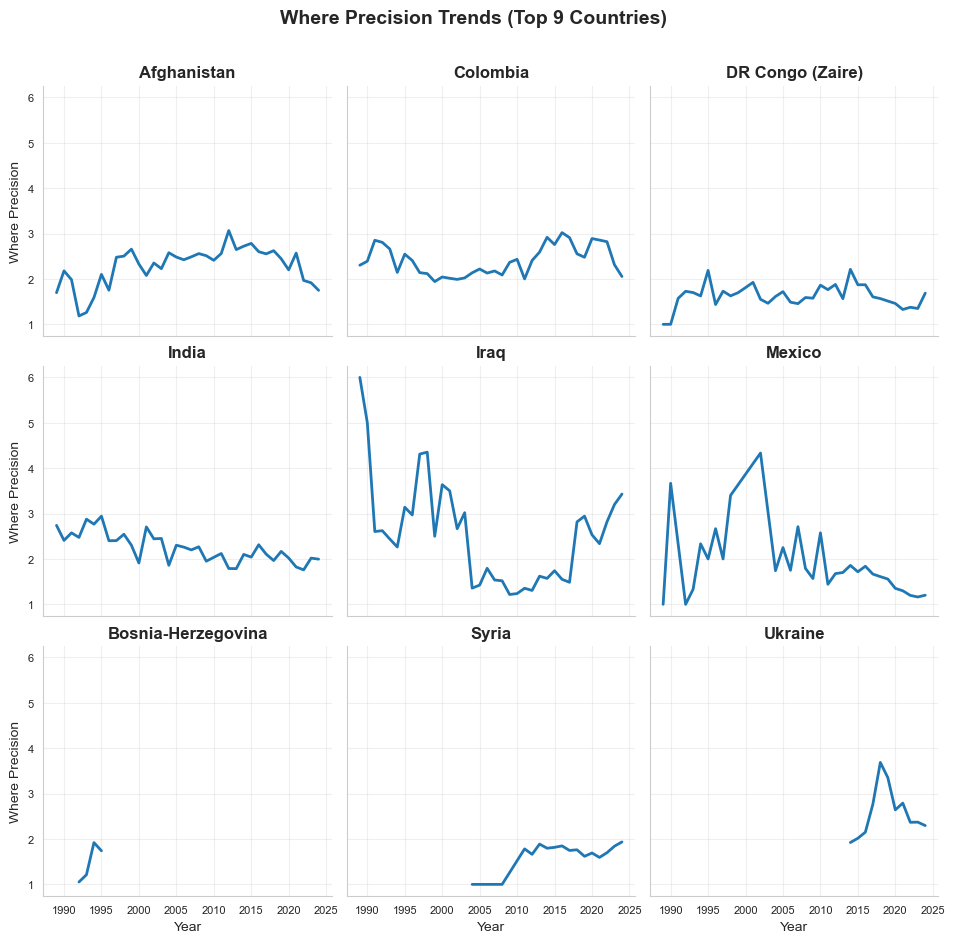

In [481]:
# Top 10 countries
top10_countries = df['country'].value_counts().head(9).index

# Filter + create year
df_top = df[df['country'].isin(top10_countries)].copy()
df_top['year'] = pd.to_datetime(df_top['date_start'], errors='coerce').dt.year

# Aggregate
country_year_stats = (
    df_top
    .groupby(['year', 'country'])['where_prec']
    .mean()
    .reset_index()
)


# Plot
g = sns.FacetGrid(
    country_year_stats,
    col='country',
    col_wrap=3,
    height=3.2,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x='year',
    y='where_prec',
    linewidth=2
)

# Titles & labels
g.set_titles("{col_name}", size=12, weight='bold')
g.set_axis_labels("Year", "Where Precision")

# Clean axes
for ax in g.axes.flatten():
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Where Precision Trends (Top 9 Countries)", fontsize=14, weight='bold')

plt.show()

####  <font color="#00ffea"> Patterns </font>

In [482]:
print(df.nlargest(10, 'best')[['region','country','type_of_violence','best', 'year', 'where_prec', 'date_prec','event_clarity', 'deaths_unknown', 'deaths_civilians']])

        region   country  type_of_violence    best  year  where_prec  \
104693  Africa  Ethiopia                 1  121848  2022           5   
104261  Africa  Ethiopia                 1  113368  2021           5   
105778  Africa  Ethiopia                 1   48183  2000           5   
222624  Africa    Rwanda                 3   40000  1994           1   
222628  Africa    Rwanda                 3   40000  1994           5   
222791  Africa    Rwanda                 3   40000  1994           1   
222033  Africa    Rwanda                 3   37000  1994           2   
105776  Africa  Ethiopia                 1   30000  1999           5   
222038  Africa    Rwanda                 3   25190  1994           2   
222773  Africa    Rwanda                 3   25000  1994           1   

        date_prec  event_clarity  deaths_unknown  deaths_civilians  
104693          5              2               0                 0  
104261          5              2               0                 0  


In [483]:
df.groupby('country')['best'].sum().sort_values(ascending=False).head(10)

country
Rwanda              794117
Ethiopia            504087
Syria               413311
Afghanistan         317793
Ukraine             245068
Mexico              141035
DR Congo (Zaire)    139381
Iraq                127241
Sudan               113439
Nigeria              73822
Name: best, dtype: int64

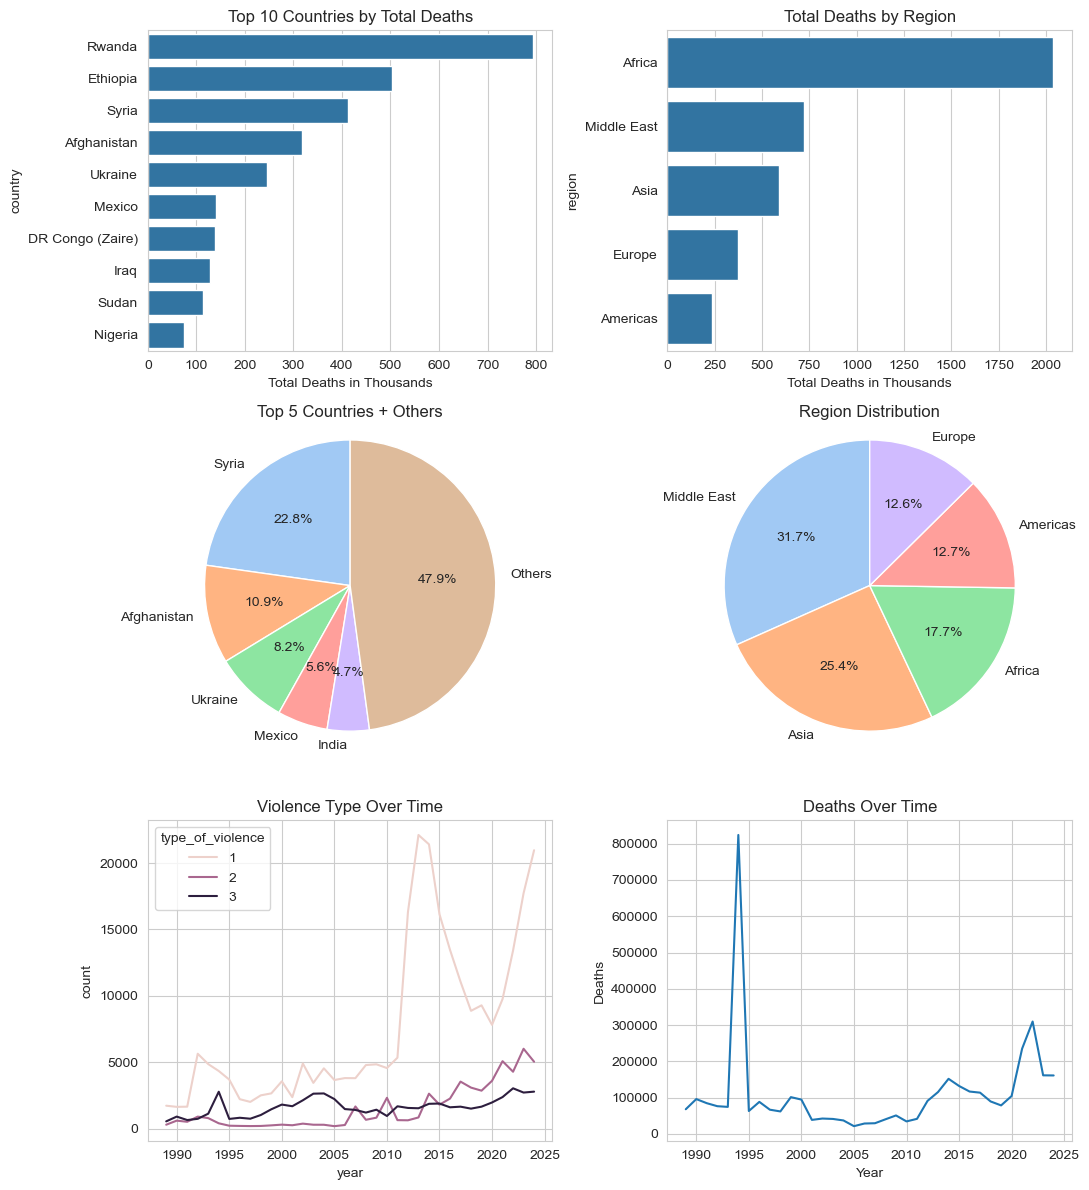

In [484]:
sns.set_style("whitegrid")

# --- 2. Top 10 countries by deaths ---
top_countries_deaths = (
    df.groupby('country')['best']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# --- 3. Top regions by deaths ---
top_regions_deaths = (
    df.groupby('region')['best']
    .sum()
    .sort_values(ascending=False)
)

# Calcular cantidades de cada especie
regions_counts = df['region'].value_counts()

# Top 5 countries and others
counts = df['country'].value_counts()

top5 = counts.head(5)
others = counts.iloc[5:].sum()

pie_data = top5.copy()
pie_data['Others'] = others

# --- PLOTS ---
fig, axes = plt.subplots(3, 2, figsize=(11, 12))

# Countries deaths
sns.barplot(
    x=(top_countries_deaths.values)/1000,  # Scale to thousands
    y=top_countries_deaths.index,
    ax=axes[0,0]
)
axes[0,0].set_title('Top 10 Countries by Total Deaths')
axes[0,0].set_xlabel('Total Deaths in Thousands')

# Regions deaths
sns.barplot(
    x=top_regions_deaths.values/1000,  # Scale to thousands
    y=top_regions_deaths.index,
    ax=axes[0,1]
)
axes[0,1].set_title('Total Deaths by Region')
axes[0,1].set_xlabel('Total Deaths in Thousands')

# --- Pie chart per Country---

axes[1, 0].pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

axes[1, 0].set_title('Top 5 Countries + Others')
axes[1, 0].axis('equal')

# --- Pie chart per Region ---
axes[1,1].pie(
    regions_counts,
    labels=regions_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

axes[1,1].set_title('Region Distribution')
axes[1,1].axis('equal')  # keep it circular

# --- 3. Violence Type Evolution ---
violence_trend = (
    df.groupby(['year', 'type_of_violence'])
    .size()
    .reset_index(name='count')
)

sns.lineplot(
    data=violence_trend,
    x='year',
    y='count',
    hue='type_of_violence',
    ax=axes[2, 0]
)
axes[2, 0].set_title('Violence Type Over Time')

deaths_trend = (
    df.groupby('year')['best']
    .sum()
    .reset_index()
)

# --- 3. Deaths Over Time ---

sns.lineplot(
    data=deaths_trend,
    x='year',
    y='best',
    ax=axes[2, 1]
)

axes[2, 1].set_title('Deaths Over Time')
axes[2, 1].set_xlabel('Year')
axes[2, 1].set_ylabel('Deaths')

plt.tight_layout()
plt.show()

##  <font color="#fbff00">3. Preprocessing and Cleaning </font>

In [496]:
df_clean_aux = df.copy()

missing_cols = df_clean_aux.columns[df_clean_aux.isna().any()]
cols_to_exclude = ['gwnob', 'gwnoa']

for col in missing_cols:

    if col in cols_to_exclude:
        print(f"Excluded: {col} - specified by user")
        continue
    
    null_percentage = df_clean_aux[col].isna().mean() # Returns a value between 0 and 1
    
    if null_percentage >= 0.05:
        df_clean_aux[col + '_missing'] = df_clean_aux[col].isna().astype(int)
        print(f"Added: {col} ({null_percentage:.2%})")
    else:
        print(f"Skipped: {col} ({null_percentage:.2%}) - below threshold")


Skipped: source_article (0.00%) - below threshold
Added: source_office (25.37%)
Added: source_date (25.37%)
Added: source_headline (25.37%)
Added: source_original (11.46%)
Skipped: where_description (2.65%) - below threshold
Added: adm_1 (5.07%)
Added: adm_2 (18.13%)
Excluded: gwnoa - specified by user
Excluded: gwnob - specified by user


- **source_article** just 1 null value

- **where_description** null values amount < 3%

- **gwnob** and **gwnoa** act like a bool type

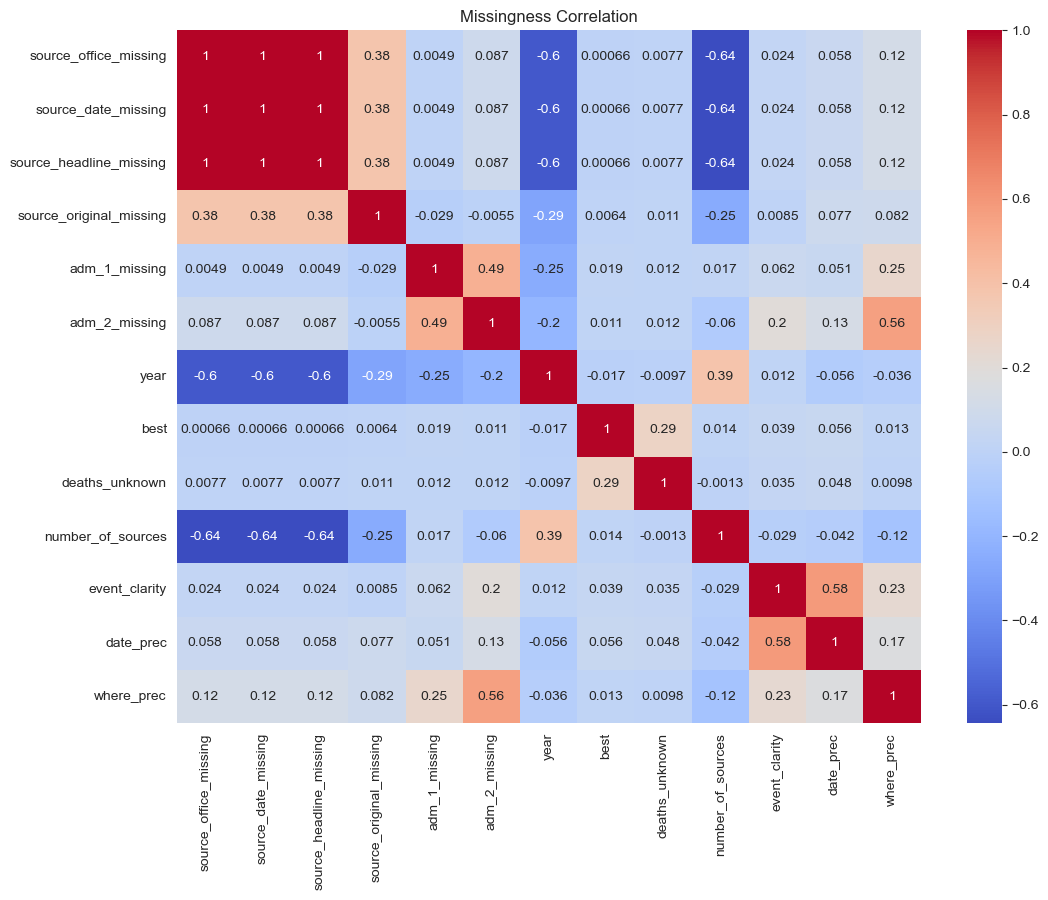

In [497]:
# 1. Dynamically find only the columns that actually exist and end with '_missing'
actual_missing_cols = [col for col in df_clean_aux.columns if col.endswith('_missing')]

# 2. Add your target variables ('year' and 'best') to that list
cols_to_correlate = actual_missing_cols + ['year', 'best', 'deaths_unknown', 'number_of_sources', 'event_clarity', 'date_prec', 'where_prec']

# 3. Run the correlation
missing_corr = df_clean_aux[cols_to_correlate].corr()

plt.figure(figsize=(12,9))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm')
plt.title('Missingness Correlation')
plt.show()

In [498]:
df_clean = df.copy()
col_clean = ['latitude', 'longitude']
df_clean.drop(columns=col_clean, errors='ignore', inplace=True)

print(df_clean.columns)

Index(['id', 'year', 'active_year', 'type_of_violence', 'conflict_new_id',
       'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a',
       'side_b_new_id', 'side_b', 'number_of_sources', 'source_article',
       'source_office', 'source_date', 'source_headline', 'source_original',
       'where_prec', 'where_coordinates', 'where_description', 'adm_1',
       'adm_2', 'country', 'country_id', 'region', 'event_clarity',
       'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b',
       'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa',
       'gwnob'],
      dtype='str')


In [499]:
# Missing values
print("\n=== Missing Values ===")
missing_data_clean = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing_data_clean = missing_data_clean.reset_index().rename(columns={'index': 'Column'})

missing_data_clean = missing_data_clean[missing_data_clean['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data_clean)


=== Missing Values ===
               Column  Missing_Count  Missing_Percentage
38              gwnob         355662               92.16
16    source_headline          97918               25.37
15        source_date          97913               25.37
14      source_office          97913               25.37
37              gwnoa          93411               24.20
22              adm_2          69977               18.13
17    source_original          44244               11.46
21              adm_1          19547                5.07
20  where_description          10243                2.65
13     source_article              1                0.00


In [503]:
# Create a flag for missing source information
source_cols = ['source_headline', 'source_date', 'source_office']
df_clean['source_missing_flag'] = df_clean[source_cols].isnull().all(axis=1).astype(int)

# Fill missing values in location and source columns with 'Unknown'
df_clean['adm_1'] = df_clean['adm_1'].fillna('Unknown')
df_clean['adm_2'] = df_clean['adm_2'].fillna('Unknown')

# Fill missing values in source_original with 'Unknown'
df_clean['source_original'] = df_clean['source_original'].fillna('Unknown')

In [504]:
# IQR Outliers
print("\n=== Numeric Features Outliers ===")
df_num_clean = df_clean.select_dtypes(include="number")
df_num_clean = df_num_clean.loc[:, ~df_num_clean.columns.str.contains('id', case=False)]

Q1 = df_num_clean.quantile(0.25)
Q3 = df_num_clean.quantile(0.75)
IQR = Q3 - Q1

outliers_mask_clean = ((df_num_clean < (Q1 - 1.5 * IQR)) | (df_num_clean > (Q3 + 1.5 * IQR)))

# Filter columns with more than 10% outliers

outliers_data_clean = pd.DataFrame({
    'Outliers_count': outliers_mask_clean.sum(),
    'Outliers_Percentage': (outliers_mask_clean.sum() / len(df_clean) * 100).round(2)
})

outliers_data_clean = outliers_data_clean.reset_index().rename(columns={'index': 'Column'})

outliers_data_clean = outliers_data_clean[outliers_data_clean['Outliers_Percentage'] > 1].sort_values('Outliers_count', ascending=False)
print(outliers_data_clean.head(10))


=== Numeric Features Outliers ===
               Column  Outliers_count  Outliers_Percentage
6            deaths_a           94908                24.59
5           date_prec           57245                14.83
7            deaths_b           57128                14.80
9      deaths_unknown           56401                14.61
10               best           50210                13.01
12                low           46614                12.08
11               high           45916                11.90
8    deaths_civilians           40484                10.49
4       event_clarity           29603                 7.67
2   number_of_sources            5192                 1.35


## <font color="#cc00ff">  Missing Data Analysis </font>

The dataset presents several patterns of missing data, which provide insights into data quality and collection processes.

A group of source-related variables (`source_headline`, `source_date`, `source_office`) shows approximately 25% missing values. These variables are perfectly correlated in their missingness, indicating that when one is missing, all are missing. This suggests a structured pattern rather than random absence, likely corresponding to events with limited or unstructured source information. This type of missingness can be classified as Missing Not At Random (MNAR), as it is likely related to the nature or quality of the event reporting.

Administrative location variables (`adm_1`, `adm_2`) also show moderate missingness (5–18%) with some correlation between them. This suggests that missingness may depend on contextual factors such as geographic precision or reporting conditions, and can be interpreted as Missing At Random (MAR).

Additionally, the missingness correlation analysis reveals a strong relationship between missing source data and time (year), indicating that older events tend to have more missing information. This reflects improvements in data collection and reporting quality over time.

Rather than removing all incomplete observations, a more appropriate strategy is to:
- Retain informative variables and explicitly encode missingness as features
- Apply simple imputation strategies for categorical and textual fields



### <font color="#d193e0">  Missing Data Interpretation (Structural Missingness)</font>

Some variables in the dataset, specifically `gwnoa` and `gwnob`, exhibit high levels of missing values. However, this missingness is not due to data quality issues but is instead structural and defined by the dataset design.

These variables represent the Gleditsch and Ward country codes for the actors involved in a conflict, and are only populated when the corresponding side is a state. If a side is a non-state actor (e.g., rebel groups, militias), the value is intentionally left empty.

Therefore, the missing values in these variables should be interpreted as meaningful information rather than absence of data. For example, the high percentage of missing values in `gwnob` indicates that in most conflicts, Side B is a non-state actor. This reflects the real-world prevalence of asymmetric conflicts between governments and non-state groups.

To better utilize this information, new binary features were created to indicate whether each side is a state actor. Additionally, a combined feature was derived to classify the type of conflict (state vs state, state vs non-state, or non-state vs non-state).

This transformation allows the model to capture the structure of conflicts more effectively while avoiding misleading interpretations of missing data.

## <font color="#cc00ff"> Outlier Analysis Interpretation </font>

The outlier detection was performed using the IQR method on numerical features. However, it is important to interpret these results carefully, as not all detected "outliers" represent errors or anomalies in the data.

First, some variables such as `date_prec` and `event_clarity` are ordinal rather than continuous. Since they take a limited set of discrete values representing categories or levels of precision, applying IQR-based outlier detection to them is not appropriate. The percentages reported for these variables do not reflect meaningful outliers and should be disregarded.

In contrast, variables related to fatalities (`deaths_a`, `deaths_b`, `deaths_civilians`, `deaths_unknown`, `best`, `low`, `high`) show a high proportion of detected outliers (ranging from ~10% to ~25%). This is expected and does not indicate data quality issues. Conflict-related data typically follows a highly skewed, heavy-tailed distribution, where most events involve few deaths, while a small number of events account for extremely large fatalities (e.g., wars, genocides, or major attacks).

Therefore, these "outliers" represent real, high-impact events rather than noise or errors. Removing them would lead to a significant loss of critical information and bias the analysis.

Instead of removing these values, a more appropriate approach is to apply transformations (such as logarithmic scaling) to reduce skewness and improve interpretability while preserving the underlying information.

In summary:
- Outliers in ordinal variables should be ignored due to methodological limitations.
- Outliers in death-related variables are meaningful and should be retained.
- The presence of many outliers reflects the real-world nature of conflict data, not data quality issues.

##  <font color="#fbff00">4. Feature Engineering </font>

In [509]:
# Create flags for whether sides are states
df_clean['side_a_is_state'] = df['gwnoa'].notnull().astype(int)
df_clean['side_b_is_state'] = df['gwnob'].notnull().astype(int)

df_clean['civilian_ratio'] = (
    df_clean['deaths_civilians'] / df_clean['best']
).replace([np.inf, -np.inf], 0).fillna(0)

print(df_clean.columns)

Index(['id', 'year', 'active_year', 'type_of_violence', 'conflict_new_id',
       'conflict_name', 'dyad_new_id', 'dyad_name', 'side_a_new_id', 'side_a',
       'side_b_new_id', 'side_b', 'number_of_sources', 'source_article',
       'source_office', 'source_date', 'source_headline', 'source_original',
       'where_prec', 'where_coordinates', 'where_description', 'adm_1',
       'adm_2', 'country', 'country_id', 'region', 'event_clarity',
       'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b',
       'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa',
       'gwnob', 'source_missing_flag', 'side_a_is_state', 'side_b_is_state',
       'intensity', 'intensity_encoded', 'civilian_ratio'],
      dtype='str')


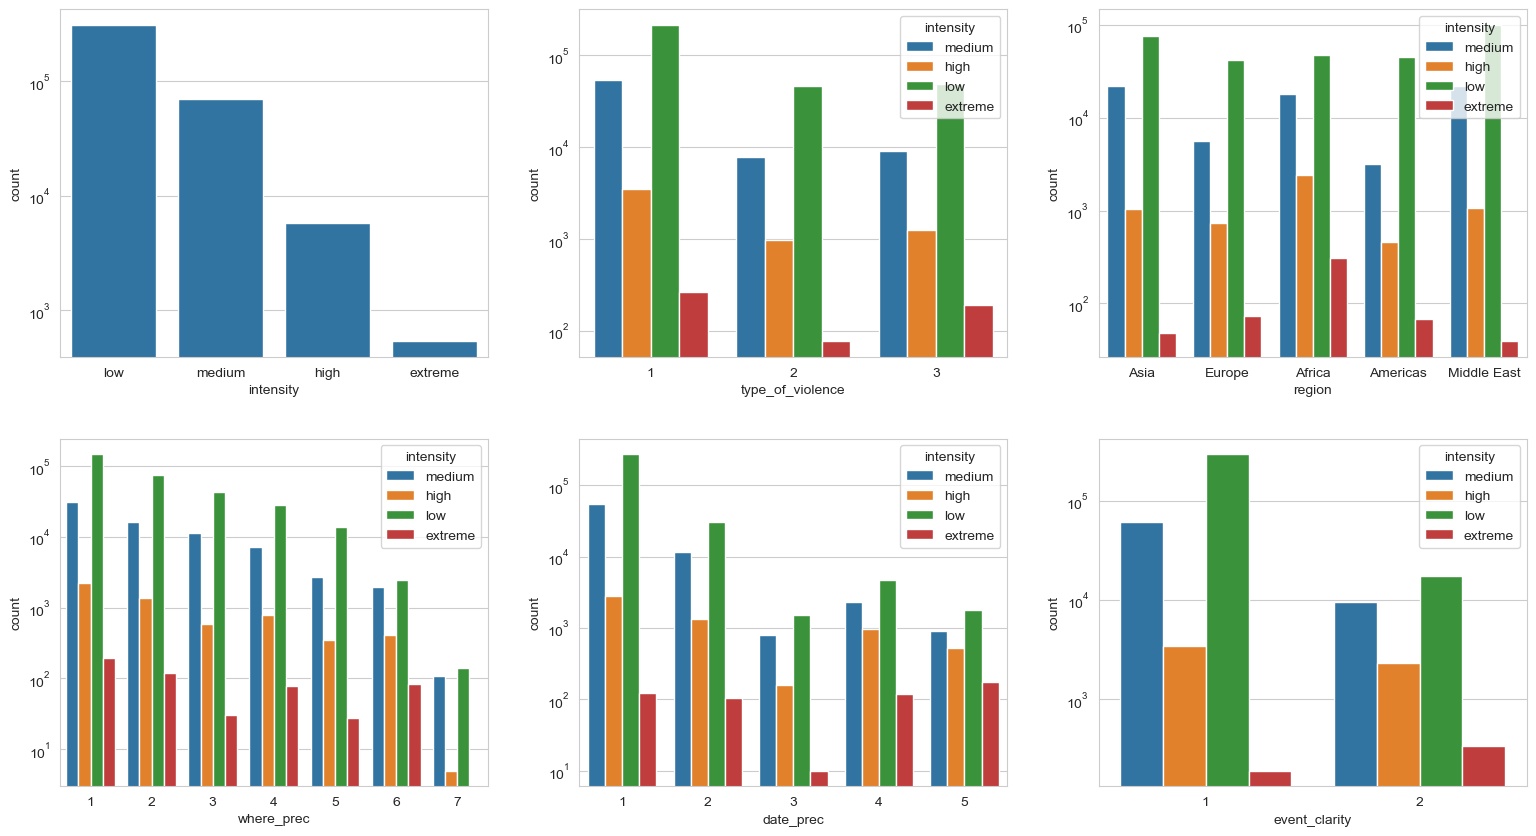

In [512]:
def classify(x):
    if x <= 5:
        return 'low'
    elif x <= 50:
        return 'medium'
    elif x <= 500:
        return 'high'
    else:
        return 'extreme'

df_clean['intensity'] = df_clean['best'].apply(classify)

mapping = {
    'low': 0,
    'medium': 1,
    'high': 2,
    'extreme': 3
}

df_clean['intensity_encoded'] = df_clean['intensity'].map(mapping)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(x='intensity', data=df_clean, order=['low','medium','high','extreme'], ax=axes[0, 0])
axes[0, 0].set_yscale('log')


sns.countplot(x='type_of_violence', hue='intensity', data=df_clean, ax=axes[0, 1])
axes[0, 1].set_yscale('log')

sns.countplot(x='region', hue='intensity', data=df_clean, ax=axes[0, 2])
axes[0, 2].set_yscale('log')

sns.countplot(x='where_prec', hue='intensity', data=df_clean, ax=axes[1, 0])
axes[1, 0].set_yscale('log')

sns.countplot(x='date_prec', hue='intensity', data=df_clean, ax=axes[1, 1])
axes[1, 1].set_yscale('log')

sns.countplot(x='event_clarity', hue='intensity', data=df_clean, ax=axes[1, 2])
axes[1, 2].set_yscale('log')


plt.tight_layout(pad=3.0) 
plt.show()

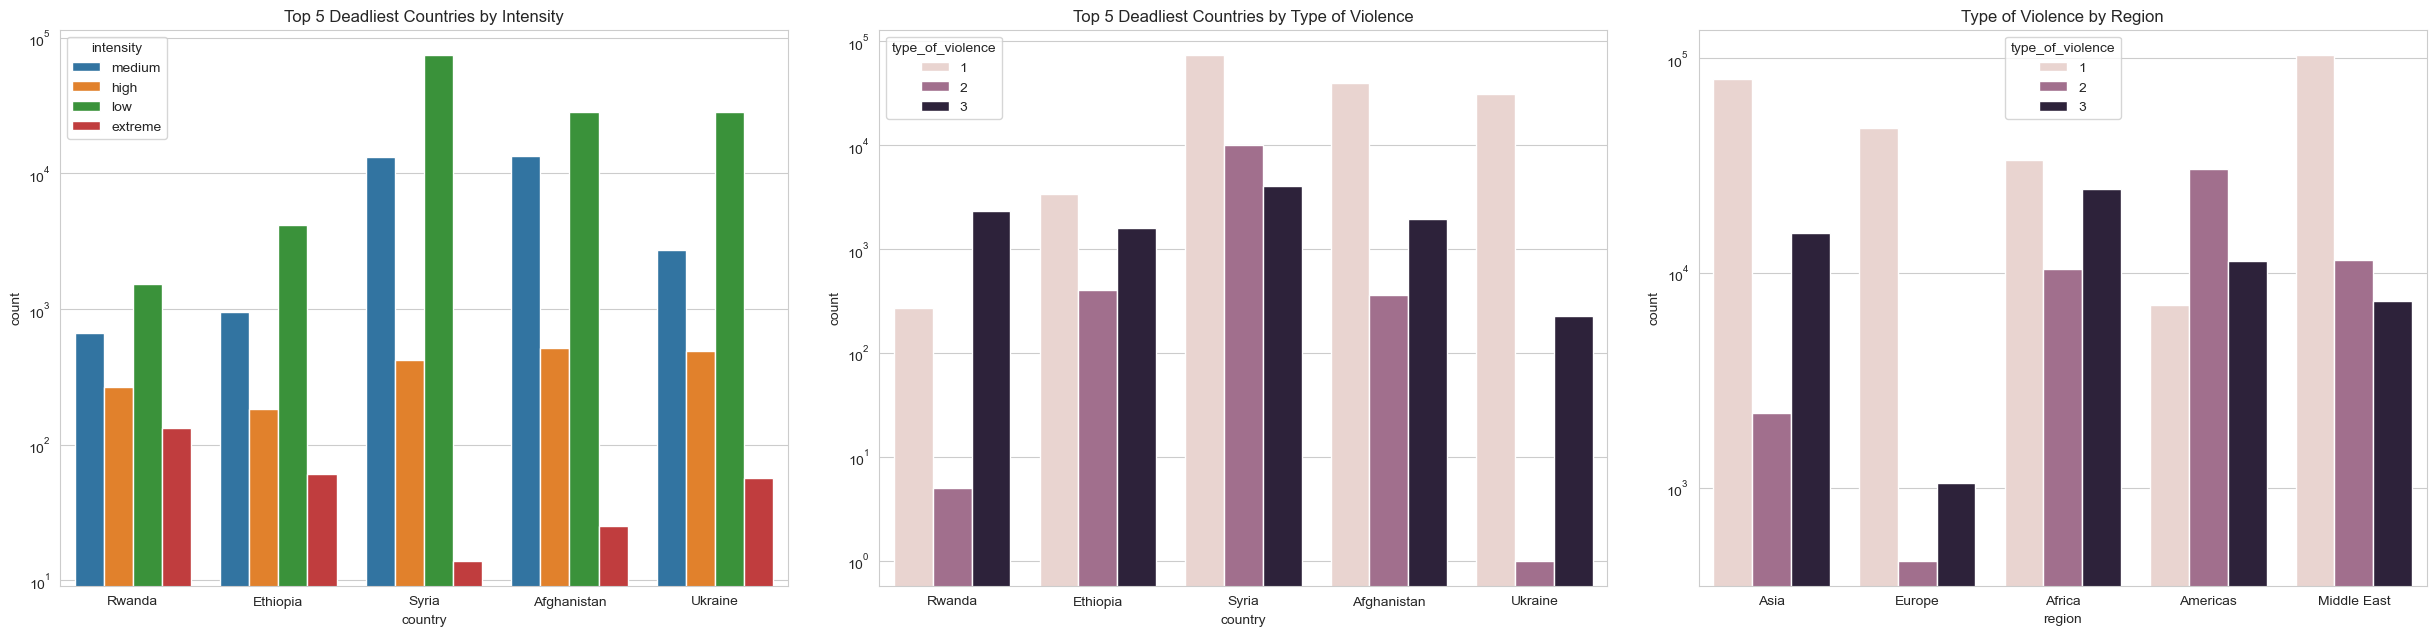

In [517]:
# Identify the top 5 countries by total death count
# Replace 'country' and 'best' with your actual column names if they differ
top_5_countries = (
    df_clean.groupby('country')['best']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# 2. Filter your original dataframe to include only these 5 countries
df_top5 = df_clean[df_clean['country'].isin(top_5_countries)]

# 3. Create the plot

fig, axes = plt.subplots(1, 3, figsize=(25, 7))

sns.countplot(
    x='country', 
    hue='intensity', 
    data=df_top5, 
    order=top_5_countries, 
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Top 5 Deadliest Countries by Intensity')

sns.countplot(
    x='country', 
    hue='type_of_violence', 
    data=df_top5, 
    order=top_5_countries, 
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Top 5 Deadliest Countries by Type of Violence')

sns.countplot(
    x='region', 
    hue='type_of_violence', 
    data=df_clean,  
    ax=axes[2]
)
axes[2].set_yscale('log')
axes[2].set_title('Type of Violence by Region')



plt.tight_layout(pad=3.0) 
plt.show()

In [493]:
#df[['intensity_encoded', 'deaths_civilians', 'deaths_a', 'deaths_b']].corr()

##  <font color="#ff00bf"> 4.2 Others </font>

In [494]:
#   Ver por que da raro
# --- 1. Conflict duration ---
"""df['date_start'] = pd.to_datetime(df['date_start'], errors='coerce')
df['date_end'] = pd.to_datetime(df['date_end'], errors='coerce')

df['duration_days'] = (df['date_end'] - df['date_start']).dt.days

conflict_duration = (
    df.groupby(['conflict_name', 'country'])
    .agg(
        start=('date_start', 'min'),
        end=('date_end', 'max')
    )
    .reset_index()
)

conflict_duration['duration_days'] = (
    conflict_duration['end'] - conflict_duration['start']
).dt.days

top_duration = conflict_duration.sort_values(
    by='duration_days', ascending=False
).head(10)"""

"df['date_start'] = pd.to_datetime(df['date_start'], errors='coerce')\ndf['date_end'] = pd.to_datetime(df['date_end'], errors='coerce')\n\ndf['duration_days'] = (df['date_end'] - df['date_start']).dt.days\n\nconflict_duration = (\n    df.groupby(['conflict_name', 'country'])\n    .agg(\n        start=('date_start', 'min'),\n        end=('date_end', 'max')\n    )\n    .reset_index()\n)\n\nconflict_duration['duration_days'] = (\n    conflict_duration['end'] - conflict_duration['start']\n).dt.days\n\ntop_duration = conflict_duration.sort_values(\n    by='duration_days', ascending=False\n).head(10)"

In [495]:
"""
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df, kde=True, stat="density", ax=axes[0], color='skyblue', label='Actual Data')

# Calculate the theoretical Normal Curve
mu, std = norm.fit(df['best'])
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Overlay the Bell Curve
axes[0].plot(x, p, 'r', linewidth=2, label=f'Normal Curve\n($\mu$={mu:.1f}, $\sigma$={std:.1f})')
axes[0].set_title("Deaths ('best') vs. Normal Distribution")
axes[0].legend()

# --- Feature 2: 'type_of_violence' (Categorical) ---
sns.countplot(x='type_of_violence', data=df, ax=axes[1], palette='viridis')
axes[1].set_title("Frequency Distribution: Type of Violence")

# --- Feature 3: 'intensity' (Categorical) ---
# Ordinal categories look best in order
intensity_order = ['low', 'medium', 'high', 'extreme']
sns.countplot(x='intensity', data=df, order=intensity_order, ax=axes[2], palette='magma')
axes[2].set_title("Frequency Distribution: Intensity")

plt.tight_layout()
plt.show()
"""

'\nfrom scipy.stats import norm\n\nfig, axes = plt.subplots(1, 3, figsize=(18, 5))\n\nsns.histplot(df, kde=True, stat="density", ax=axes[0], color=\'skyblue\', label=\'Actual Data\')\n\n# Calculate the theoretical Normal Curve\nmu, std = norm.fit(df[\'best\'])\nxmin, xmax = axes[0].get_xlim()\nx = np.linspace(xmin, xmax, 100)\np = norm.pdf(x, mu, std)\n\n# Overlay the Bell Curve\naxes[0].plot(x, p, \'r\', linewidth=2, label=f\'Normal Curve\n($\\mu$={mu:.1f}, $\\sigma$={std:.1f})\')\naxes[0].set_title("Deaths (\'best\') vs. Normal Distribution")\naxes[0].legend()\n\n# --- Feature 2: \'type_of_violence\' (Categorical) ---\nsns.countplot(x=\'type_of_violence\', data=df, ax=axes[1], palette=\'viridis\')\naxes[1].set_title("Frequency Distribution: Type of Violence")\n\n# --- Feature 3: \'intensity\' (Categorical) ---\n# Ordinal categories look best in order\nintensity_order = [\'low\', \'medium\', \'high\', \'extreme\']\nsns.countplot(x=\'intensity\', data=df, order=intensity_order, ax=axes

##  <font color="#ff00bf">Features Summary </font>

### 1. **Conflict & Actor Metadata**:
These features define who is fighting and what kind of violence is occurring.
- **type_of_violence**: Categorizes the event into one of three mutually exclusive types:
    - 1 (State-based): A conflict where at least one side is a government. Example: Government of Colombia vs. FARC.
    - 2 (Non-state): Fighting between two organized groups, neither of which is a government. Example: Two rival cartels or ethnic militias fighting each other.
    - 3 (One-sided): An organized group (government or rebel) attacking unarmed civilians. Example: An extremist group attacking a village.side_a / side_b: The names of the two parties in the "dyad" (pair).In State-based, side_a is always the Government.In One-sided, side_b is always listed as "civilians".
- **side_a / side_b**: The names of the two parties in the "dyad" (pair). In State-based, side_a is always the Government. In One-sided, side_b is always listed as "civilians".
- **conflict_new_id / dyad_new_id**: Numerical "tracking codes".
    - Conflict ID: Groups all events related to the same core issue (the "War").
    - Dyad ID: Identifies the specific pair of opponents. A single conflict can have multiple dyads if different rebel groups fight the same government over the same issue.
- **adm_1**: Name of the first-order (largest) administrative division (e.g., Province).
- **adm_2**: Name of the second-order administrative division (e.g., District).

- **gwnoa / gwnob**: The Gleditsch and Ward country code. This is a standard numeric ID for recognized states (e.g., France = 220). It is empty if the actor is not a state government (like a rebel group).
- **active_year**: A binary flag (1 or 0). It is 1 if the conflict resulted in at least 25 deaths during that specific calendar year.

### 2. **Geographical & Temporal Features**: These features explain where and when the violence happened.
- **country**: Name of the country in which the event took place.
- **region**: The broad geographic region of the event: Africa, Americas, Asia, Europe, or Middle East.
- **where_coordinates**: The specific name of the location (town, village, etc.)
- **latitude / longitude**: The exact GPS-style coordinates
- **where_prec** : The precision of the location on a scale of 1 to 7.
    - 1: Exact location is known.
    - 4: Only the province (ADM1) is known.
    - 6: Only the country is known.
- **date_start / date_end**: The timeframe of the incident. If the exact day is known, these dates are the same.
- **date_prec**: How accurately the date is known.
    - 1: Exact day.
    - 5: Only the year is known.


### 3. **Fatality Figures** These features provide the "death toll" for the event. To handle reporting uncertainty, UCDP provides an interval.
- **best**: The most reliable and likely estimate of total deaths.
- **high / low**: The highest and lowest reliable numbers found in source reports.
- **deaths_civilians**: Specifically tracks deaths of unarmed people.
    - In One-sided violence, this is the main fatality count.
    - In State-based/Non-state, this represents "collateral damage" from the fighting.

### 4. **Information Sources (Data Provenance)** Critical for understanding the origin and reliability of the reported incident.
- **number_of_sources**: Total sources consulted for the event. Note: Available for data since 2013; older data defaults to -1.
- **source_article**: References to names, dates, and titles of source materials; available for all events.
- **source_office**: The organizations publishing the text (e.g., Reuters, BBC); field is empty for older data.
- **source_date**: Publication date of the source; defaults to 1753-01-01 if missing.
- **source_headline**: The title of the source material.source_original: The original source of the info (e.g., "police", "eyewitnesses", "rebel spokesman").

### 5. **Data Quality Features**
- **event_clarity**:
    - 1 (High): A specific, clear incident. Example: "A bomb at a market on Tuesday."
    - 2 (Low): An aggregate report that cannot be broken down. Example: "20 people died in various clashes last week." 